# NGHIÊN CỨU THUẬT TOÁN V2: TỐI ƯU HÓA DỰ ĐOÁN SINH VIÊN BỎ HỌC
## Kết hợp Tối ưu siêu tham số (Optuna), Giải thích Học máy (SHAP) và Đồ thị tri thức (PyG)

Phiên bản nâng cấp này tích hợp **Optuna** - một framework tối ưu hóa siêu tham số thế hệ mới dựa trên thuật toán lựa chọn phân phối xác suất (Tree-structured Parzen Estimator - TPE). Kỹ thuật này giúp tự động hóa việc tìm kiếm cấu hình không gian tham số tối ưu cho LightGBM, thay thế cho các phương pháp thô sơ như Grid Search hay Random Search.

---


## Bước 1: Khởi tạo môi trường & Giả lập Tập dữ liệu Nghiên cứu
Đảm bảo các thư viện cốt lõi bao gồm cả `optuna` đã được import.


In [1]:
import os
import pandas as pd
import numpy as np
import torch
import lightgbm as lgb
import shap
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support, fbeta_score

## Bước 2: Khởi tạo Pipeline Tiền xử lý Dữ liệu
Chuẩn hóa Z-score cho đặc trưng số và One-hot cho đặc trưng phân loại.


In [ ]:
df = pd.read_csv("../data/student_dropout.csv")
target = 'Dropout'
cat_features = df.select_dtypes(include='object').columns.tolist()
num_features = df.select_dtypes(include='number').columns.tolist()
num_features.remove(target)

df = df.astype(dict(zip(cat_features, ['category' for _ in range(len(cat_features))])))
X = df.loc[:, cat_features + num_features]
y = df.loc[:, target]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=8894, stratify=y) # random.org to choose
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=4173, stratify=y_train_val) # random.org to choose random_state

## Bước 3: Tối ưu hóa siêu tham số tự động với Optuna
Chúng ta thiết lập một hàm mục tiêu (`objective`) nhận vào một `trial` từ Optuna. Đối tượng này sẽ định nghĩa không gian tìm kiếm phi tuyến cho các siêu tham số quan trọng của LightGBM, hướng tới tối đa hóa chỉ số $F_\beta$ score, với $\beta=2$.


In [3]:
df.dtypes

Student_ID                  int64
Age                       float64
Gender                   category
Family_Income             float64
Internet_Access          category
Study_Hours_per_Day       float64
Attendance_Rate           float64
Assignment_Delay_Days       int64
Travel_Time_Minutes       float64
Part_Time_Job            category
Scholarship              category
Stress_Index              float64
GPA                       float64
Semester_GPA              float64
CGPA                      float64
Semester                 category
Department               category
Parental_Education       category
Dropout                     int64
dtype: object

In [4]:
model_callbacks = [lgb.early_stopping(10)]

def objective(trial: optuna.trial.Trial):
    # Định nghĩa không gian tìm kiếm siêu tham số
    params = {
        'n_estimators': 1000, # use early stopping
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced',
        'random_state': 1955,
        'verbose': -1
    }
    
    # Huấn luyện mô hình tạm thời
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, callbacks=model_callbacks, eval_set=(X_val, y_val))
    
    # Dự đoán xác suất trên tập validation
    preds = model.predict(X_val)
    score = fbeta_score(y_val, preds, beta=2)
    return score

print('--- KHỞI CHẠY TIẾN TRÌNH TỐI ƯU HÓA OPTUNA (50 TRIALS) ---')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print('\nQuá trình tối ưu hoàn tất!')
print(f'ROC-AUC tối ưu đạt được: {study.best_value:.4f}')
print('Bộ siêu tham số tốt nhất:')
for key, value in study.best_params.items():
    print(f'  - {key}: {value}')


[I 2026-06-29 23:49:08,300] A new study created in memory with name: no-name-d6be353f-f1c5-4cd5-beef-938af4d44650


--- KHỞI CHẠY TIẾN TRÌNH TỐI ƯU HÓA OPTUNA (50 TRIALS) ---
Training until validation scores don't improve for 10 rounds


[I 2026-06-29 23:49:08,662] Trial 0 finished with value: 0.6065400843881856 and parameters: {'learning_rate': 0.037499005486766684, 'max_depth': 10, 'num_leaves': 53, 'min_child_samples': 37, 'subsample': 0.6886096877987617, 'colsample_bytree': 0.9533841627613882}. Best is trial 0 with value: 0.6065400843881856.


Early stopping, best iteration is:
[106]	valid_0's binary_logloss: 0.514564
Training until validation scores don't improve for 10 rounds


[I 2026-06-29 23:49:09,367] Trial 1 finished with value: 0.574398249452954 and parameters: {'learning_rate': 0.02731467073601526, 'max_depth': 11, 'num_leaves': 109, 'min_child_samples': 28, 'subsample': 0.7016773459353105, 'colsample_bytree': 0.6955730413708753}. Best is trial 0 with value: 0.6065400843881856.


...

Early stopping, best iteration is:
[236]	valid_0's binary_logloss: 0.523764
Training until validation scores don't improve for 10 rounds


[I 2026-06-29 23:49:20,785] Trial 47 finished with value: 0.6074766355140186 and parameters: {'learning_rate': 0.04382771890701392, 'max_depth': 5, 'num_leaves': 37, 'min_child_samples': 60, 'subsample': 0.8334935487772563, 'colsample_bytree': 0.9800701393035739}. Best is trial 24 with value: 0.6304459251665813.
[I 2026-06-29 23:49:20,963] Trial 48 finished with value: 0.6127197518097208 and parameters: {'learning_rate': 0.055151542797182256, 'max_depth': 6, 'num_leaves': 47, 'min_child_samples': 95, 'subsample': 0.7682758265392341, 'colsample_bytree': 0.7131468724052669}. Best is trial 24 with value: 0.6304459251665813.


Early stopping, best iteration is:
[99]	valid_0's binary_logloss: 0.526768
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[74]	valid_0's binary_logloss: 0.526214


[I 2026-06-29 23:49:21,108] Trial 49 finished with value: 0.6160164271047228 and parameters: {'learning_rate': 0.03657794416963671, 'max_depth': 3, 'num_leaves': 88, 'min_child_samples': 71, 'subsample': 0.8678484461715575, 'colsample_bytree': 0.959822829776127}. Best is trial 24 with value: 0.6304459251665813.


Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[119]	valid_0's binary_logloss: 0.533618

Quá trình tối ưu hoàn tất!
ROC-AUC tối ưu đạt được: 0.6304
Bộ siêu tham số tốt nhất:
  - learning_rate: 0.1264908911000766
  - max_depth: 3
  - num_leaves: 46
  - min_child_samples: 91
  - subsample: 0.8304501923245355
  - colsample_bytree: 0.934513945054747


## Bước 4: Huấn luyện Mô hình Tối ưu và Trích xuất Đồ thị SHAP
Sử dụng cấu hình tốt nhất tìm được từ Optuna để cấu trúc lại mô hình LightGBM chính thức, sau đó tiến hành phân tích độ tường minh bằng SHAP.


In [ ]:
def classification_report_f2(y_true, y_pred):
    # Tính toán precision, recall, f2-score cho từng lớp với beta=2
    precision, recall, f2_score, support = precision_recall_fscore_support(
        y_true, y_pred, beta=2, labels=[0, 1]
    )
    
    # Tạo DataFrame để hiển thị cấu trúc giống classification_report
    report_df = pd.DataFrame({
        'Precision': precision,
        'Recall': recall,
        'F2-score': f2_score,
        'Support': support
    }, index=['Sinh viên ở lại (Lớp 0)', 'Sinh viên bỏ học (Lớp 1)'])
    
    return report_df

--- HUẤN LUYỆN LIGHTGBM VỚI BỘ THAM SỐ TỐI ƯU ---

[KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SAU TỐI ƯU HÓA]
Tối ưu f_2 Score: 0.4040
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1147
           1       0.57      0.38      0.45       353

    accuracy                           0.79      1500
   macro avg       0.70      0.64      0.66      1500
weighted avg       0.77      0.79      0.77      1500

--- XÂY DỰNG KHÔNG GIAN GIẢI THÍCH SHAP ---
Đồ thị 1: Tầm quan trọng đặc trưng toàn cục (Beeswarm Plot)


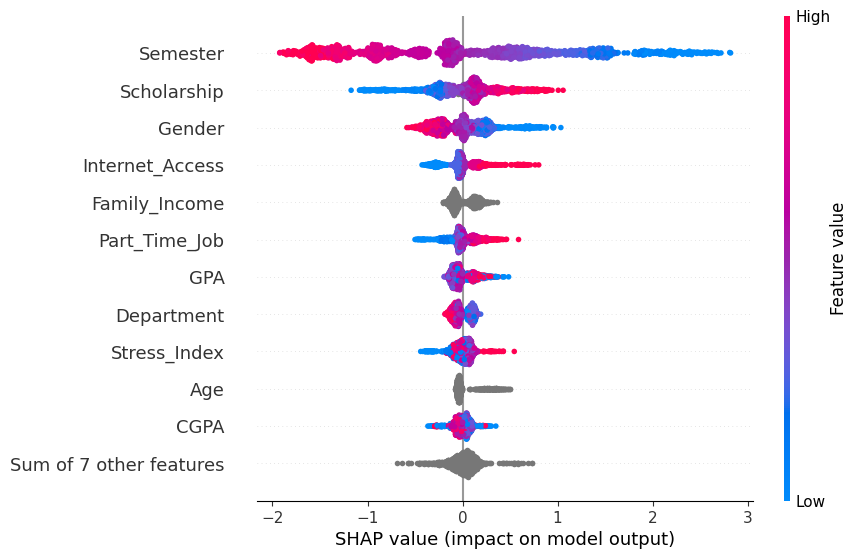


Đồ thị 2: Căn nguyên rủi ro cá nhân hóa của sinh viên đầu tiên (Waterfall Plot)


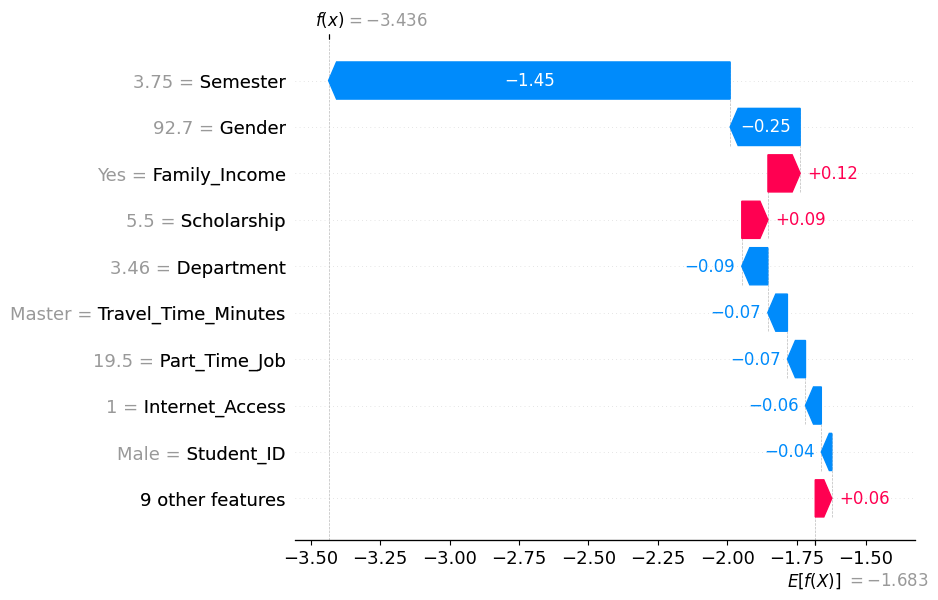

In [5]:
print('--- HUẤN LUYỆN LIGHTGBM VỚI BỘ THAM SỐ TỐI ƯU ---')
best_params = study.best_params

best_clf = lgb.LGBMClassifier(**best_params)
best_clf.fit(X_train, y_train)

y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict(X_test)

print('\n[KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SAU TỐI ƯU HÓA]')
print(f'Tối ưu f_2 Score: {fbeta_score(y_test, y_prob, beta=2):.4f}')
print(classification_report_f2(y_test, y_pred))

print('--- XÂY DỰNG KHÔNG GIAN GIẢI THÍCH SHAP ---')
explainer = shap.TreeExplainer(best_clf)
shap_values = explainer(X_test)
shap_values.feature_names = num_features + cat_features

if len(shap_values.shape) == 3:
    shap_values_target = shap_values[:, :, 1]
else:
    shap_values_target = shap_values

print('Đồ thị 1: Tầm quan trọng đặc trưng toàn cục (Beeswarm Plot)')
shap.plots.beeswarm(shap_values_target, max_display=12)

print('\nĐồ thị 2: Căn nguyên rủi ro cá nhân hóa của sinh viên đầu tiên (Waterfall Plot)')
shap.plots.waterfall(shap_values_target[0])


## Hướng tiếp cận 2: Đồ thị tri thức & Heterogeneous Graph Neural Networks
Cấu trúc đồ thị không đồng nhất giữ nguyên từ thiết kế nghiên cứu ban đầu nhằm so sánh tương quan.


In [ ]:
num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_features), ('cat', cat_transformer, cat_features)])
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

encoded_cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_features)
all_features_names = np.concatenate([num_features, encoded_cat_features])

In [ ]:
try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import SAGEConv, to_hetero
    PYG_AVAILABLE = True
except ImportError:
    PYG_AVAILABLE = False

if PYG_AVAILABLE:
    graph_data = HeteroData()
    num_students = len(df)
    
    student_features = df[num_features].fillna(df[num_features].median()).values
    graph_data['student'].x = torch.tensor(student_features, dtype=torch.float)
    graph_data['student'].y = torch.tensor(df[target].values, dtype=torch.long)
    
    df['dept_idx'] = df['Department'].astype('category').cat.codes
    df['income_idx'] = df['Family_Income'].astype('category').cat.codes
    
    num_depts = len(df['Department'].unique())
    num_incomes = len(df['Family_Income'].unique())
    
    graph_data['department'].x = torch.eye(num_depts, dtype=torch.float)
    graph_data['income_bracket'].x = torch.eye(num_incomes, dtype=torch.float)
    
    student_nodes = torch.arange(num_students, dtype=torch.long)
    dept_edges = torch.stack([student_nodes, torch.tensor(df['dept_idx'].values, dtype=torch.long)], dim=0)
    income_edges = torch.stack([student_nodes, torch.tensor(df['income_idx'].values, dtype=torch.long)], dim=0)
    
    graph_data['student', 'studies_in', 'department'].edge_index = dept_edges
    graph_data['student', 'has_income', 'income_bracket'].edge_index = income_edges
    
    indices = np.arange(num_students)
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=df[target].values)
    
    train_mask = torch.zeros(num_students, dtype=torch.bool)
    test_mask = torch.zeros(num_students, dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True
    
    graph_data['student'].train_mask = train_mask
    graph_data['student'].test_mask = test_mask
    
    class HeteroGNN(torch.nn.Module):
        def __init__(self, hidden_channels, out_channels):
            super().__init__()
            self.conv1 = SAGEConv((-1, -1), hidden_channels)
            self.conv2 = SAGEConv((-1, -1), out_channels)
        def forward(self, x_dict, edge_index_dict):
            x_dict = {key: self.conv1(x, edge_index_dict[key]).relu() for key, x in x_dict.items()}
            x_dict = {key: self.conv2(x, edge_index_dict[key]) for key, x in x_dict.items()}
            return x_dict
            
    base_model = HeteroGNN(hidden_channels=32, out_channels=2)
    model = to_hetero(base_model, graph_data.metadata(), aggr='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    
    print('--- HUẤN LUYỆN GRAPH NEURAL NETWORK ---')
    for epoch in range(1, 31):
        model.train()
        optimizer.zero_grad()
        out = model(graph_data.x_dict, graph_data.edge_index_dict)
        loss = criterion(out['student'][graph_data['student'].train_mask], graph_data['student'].y[graph_data['student'].train_mask])
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        logits = model(graph_data.x_dict, graph_data.edge_index_dict)['student']
        probs = torch.softmax(logits, dim=-1)[:, 1].numpy()[test_idx]
        preds = logits.argmax(dim=-1).numpy()[test_idx]
        true_y = graph_data['student'].y.numpy()[test_idx]
    print(f'Graph ROC-AUC Score: {roc_auc_score(true_y, probs):.4f}')
else:
    print('Cài đặt thư viện: !pip install torch-geometric để kích hoạt chạy phần Graph ML.')


## Bước 5: Tổng kết thực nghiệm
Việc tích hợp Optuna giúp tự động hóa quá trình dò tìm tổ hợp siêu tham số tối ưu (như `num_leaves`, `learning_rate`...), đẩy hiệu năng của LightGBM lên điểm bão hòa chính xác cao nhất mà cấu trúc dữ liệu bảng cung cấp, tạo tiền đề vững chắc để đối chứng với hướng tiếp cận Đồ thị tri thức.
